<a href="https://colab.research.google.com/github/SammyBoi242006/CCPS_project/blob/main/models/final_model_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install albumentations timm -q

print("Done!")

Mounted at /content/drive
Done!


In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
import torch.nn.functional as F



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [3]:
PLANTVILLAGE = '/content/drive/MyDrive/project/data/plantvillage_tomato/PlantVillage'
RESULTS      = '/content/drive/MyDrive/project/results'
MODELS       = '/content/drive/MyDrive/project/models'
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(MODELS,  exist_ok=True)

SELECTED_CLASSES = [
    'Tomato_healthy',
    'Tomato_Bacterial_spot',
    'Tomato_Early_blight',
    'Tomato_Late_blight',
    'Tomato__Tomato_YellowLeaf__Curl_Virus'
]

CONFIG = {
    'image_size'  : 224,
    'batch_size'  : 32,
    'num_workers' : 2,
    'epochs'      : 50,
    'lr'          : 1e-4,
    'seed'        : 42,
    'num_classes' : 5,
    'mean'        : [0.485, 0.456, 0.406],
    'std'         : [0.229, 0.224, 0.225],
}

class_to_idx = {cls: idx for idx, cls in enumerate(SELECTED_CLASSES)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}
short_names  = ['Healthy', 'Bacterial Spot', 'Early Blight',
                'Late Blight', 'Yellow Leaf Curl']

print("Classes:")
for cls, idx in class_to_idx.items():
    print(f"  {idx}: {cls}")

Classes:
  0: Tomato_healthy
  1: Tomato_Bacterial_spot
  2: Tomato_Early_blight
  3: Tomato_Late_blight
  4: Tomato__Tomato_YellowLeaf__Curl_Virus


In [4]:
torch.manual_seed(CONFIG['seed'])

all_paths, all_labels = [], []

for cls in SELECTED_CLASSES:
    cls_path = os.path.join(PLANTVILLAGE, cls)
    for img_file in os.listdir(cls_path):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_paths.append(os.path.join(cls_path, img_file))
            all_labels.append(class_to_idx[cls])

print(f"Total images: {len(all_paths)}")
for idx, name in enumerate(short_names):
    print(f"  {name}: {all_labels.count(idx)}")

# 80% train, 20% temp
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.20,
    stratify=all_labels,
    random_state=CONFIG['seed']
)

# Split temp equally into 10% val, 10% test
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=CONFIG['seed']
)

print(f"\nTrain : {len(train_paths)} (80%)")
print(f"Val   : {len(val_paths)}   (10%)")
print(f"Test  : {len(test_paths)}  (10%)")

Total images: 9835
  Healthy: 1591
  Bacterial Spot: 2127
  Early Blight: 1000
  Late Blight: 1909
  Yellow Leaf Curl: 3208

Train : 7868 (80%)
Val   : 983   (10%)
Test  : 984  (10%)


In [5]:
train_transform = A.Compose([
    A.Resize(CONFIG['image_size'], CONFIG['image_size']),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=15, p=0.5),
    A.RandomResizedCrop(
        size=(CONFIG['image_size'], CONFIG['image_size']),
        scale=(0.8, 1.0), ratio=(0.9, 1.1), p=0.5
    ),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1, p=0.5),
    A.RandomShadow(p=0.3),
    A.CoarseDropout(max_holes=8, max_height=20, max_width=20, p=0.3),
    A.GaussNoise(var_limit=(10, 50), p=0.3),
    A.MotionBlur(blur_limit=5, p=0.2),
    A.GaussianBlur(blur_limit=3, p=0.2),
    A.Normalize(mean=CONFIG['mean'], std=CONFIG['std']),
    ToTensorV2()
])

val_test_transform = A.Compose([
    A.Resize(CONFIG['image_size'], CONFIG['image_size']),
    A.Normalize(mean=CONFIG['mean'], std=CONFIG['std']),
    ToTensorV2()
])

print("Transforms ready.")

Transforms ready.


/tmp/ipykernel_2905/204584386.py:12: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=20, max_width=20, p=0.3),
/tmp/ipykernel_2905/204584386.py:13: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.3),


In [6]:
class TomatoDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img   = np.array(Image.open(self.paths[idx]).convert('RGB'))
        label = self.labels[idx]
        if self.transform:
            img = self.transform(image=img)['image']
        return img, label

train_dataset = TomatoDataset(train_paths, train_labels, train_transform)
val_dataset   = TomatoDataset(val_paths,   val_labels,   val_test_transform)
test_dataset  = TomatoDataset(test_paths,  test_labels,  val_test_transform)

print(f"Train : {len(train_dataset)}")
print(f"Val   : {len(val_dataset)}")
print(f"Test  : {len(test_dataset)}")

Train : 7868
Val   : 983
Test  : 984


In [7]:
class_counts   = Counter(train_labels)
class_weights  = {cls: 1.0 / count for cls, count in class_counts.items()}
sample_weights = torch.tensor([class_weights[l] for l in train_labels], dtype=torch.float)
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'],
                          sampler=sampler, num_workers=CONFIG['num_workers'],
                          pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size'],
                          shuffle=False,  num_workers=CONFIG['num_workers'],
                          pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'],
                          shuffle=False,  num_workers=CONFIG['num_workers'],
                          pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 246
Val batches   : 31
Test batches  : 31


In [8]:
class MultiScaleStem(nn.Module):
    """
    Novelty 1 — Three parallel kernels capture disease
    features at multiple physical scales simultaneously.
    """
    def __init__(self):
        super().__init__()
        self.branch_3x3 = nn.Sequential(
            nn.Conv2d(3, 21, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(21), nn.ReLU()
        )
        self.branch_5x5 = nn.Sequential(
            nn.Conv2d(3, 21, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(21), nn.ReLU()
        )
        self.branch_7x7 = nn.Sequential(
            nn.Conv2d(3, 22, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm2d(22), nn.ReLU()
        )
        self.compress = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU()
        )

    def forward(self, x):
        b3  = self.branch_3x3(x)
        b5  = self.branch_5x5(x)
        b7  = self.branch_7x7(x)
        out = torch.cat([b3, b5, b7], dim=1)
        return self.compress(out)

print("MultiScaleStem defined.")

MultiScaleStem defined.


In [9]:
class SEModule(nn.Module):
    """
    Novelty 2 — Channel attention learns which channels
    represent true disease signal vs noise.
    """
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.se(x).view(x.size(0), x.size(1), 1, 1)
        return x * w


class DepthwiseSeparableBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=2, use_se=False):
        super().__init__()
        self.dw = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, kernel_size=3, stride=stride,
                      padding=1, groups=in_ch, bias=False),
            nn.GroupNorm(num_groups=min(32, in_ch), num_channels=in_ch),
            nn.ReLU()
        )
        self.pw = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
            nn.GroupNorm(num_groups=min(32, out_ch), num_channels=out_ch),
            nn.ReLU()
        )
        self.se      = SEModule(out_ch) if use_se else nn.Identity()
        self.dropout = nn.Dropout2d(0.1)

    def forward(self, x):
        x = self.dw(x)
        x = self.pw(x)
        x = self.se(x)
        return self.dropout(x)

print("SEModule and DepthwiseSeparableBlock defined.")

SEModule and DepthwiseSeparableBlock defined.


In [10]:
class CNNBranch(nn.Module):
    """
    Custom CNN with:
    - Multi-Scale Stem (Novelty 1)
    - SE Module (Novelty 2)
    - GeM Pooling (Novelty 4) replacing standard GAP
    """
    def __init__(self):
        super().__init__()
        self.stem   = MultiScaleStem()
        self.block1 = DepthwiseSeparableBlock(64,  128, use_se=False)
        self.block2 = DepthwiseSeparableBlock(128, 256, use_se=True)
        self.block3 = DepthwiseSeparableBlock(256, 512, use_se=False)

        # Novelty 4 — GeM pooling, learned exponent initialized at 3.0
        self.gem_p  = nn.Parameter(torch.ones(1) * 3.0)
        self.flat   = nn.Flatten()

    def gem_pool(self, x):
        # Clamp prevents numerical issues with near-zero values
        x = x.clamp(min=1e-6).pow(self.gem_p)
        x = x.mean(dim=[2, 3])
        return x.pow(1.0 / self.gem_p)

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gem_pool(x)     # GeM instead of GAP
        return self.flat(x)      # 512-dim vector

print("CNNBranch with GeM defined.")

CNNBranch with GeM defined.


In [11]:
class CAFormerBranch(nn.Module):
    """
    Pretrained CAFormer-s18 with selective freezing.
    Stages 1-2 frozen, Stage 3 partial, Stage 4 full.
    """
    def __init__(self):
        super().__init__()
        self.caformer = timm.create_model(
            'caformer_s18', pretrained=True, num_classes=0
        )

        # Freeze everything first
        for param in self.caformer.parameters():
            param.requires_grad = False

        # Unfreeze Stage 4 fully
        for param in self.caformer.stages[3].parameters():
            param.requires_grad = True

        # Unfreeze last 2 blocks of Stage 3
        stage3_blocks = list(self.caformer.stages[2].blocks)
        for block in stage3_blocks[-2:]:
            for param in block.parameters():
                param.requires_grad = True

        # Unfreeze head if exists
        if hasattr(self.caformer, 'head'):
            for param in self.caformer.head.parameters():
                param.requires_grad = True

    def forward(self, x):
        return self.caformer(x)   # 512-dim vector

print("CAFormerBranch defined.")

CAFormerBranch defined.


In [12]:
class CBSEF(nn.Module):
    """
    Novelty 3 — Cross-Branch SE Fusion.
    Learns to dynamically weight CNN vs CAFormer
    features per disease class.
    """
    def __init__(self, feature_dim=1024, reduction=16):
        super().__init__()
        self.se_gate = nn.Sequential(
            nn.Linear(feature_dim, feature_dim // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(feature_dim // reduction, feature_dim, bias=False),
            nn.Sigmoid()
        )

    def forward(self, cnn_feat, trans_feat):
        combined = torch.cat([cnn_feat, trans_feat], dim=1)
        gate     = self.se_gate(combined)
        gated    = combined * gate
        return gated + combined   # residual connection

print("CBSEF defined.")

CBSEF defined.


In [13]:
class FullHybridModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.cnn_branch   = CNNBranch()
        self.trans_branch = CAFormerBranch()
        self.fusion       = CBSEF(feature_dim=1024, reduction=16)
        self.classifier   = nn.Sequential(
            nn.Linear(1024, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        cnn_feat   = self.cnn_branch(x)
        trans_feat = self.trans_branch(x)
        fused      = self.fusion(cnn_feat, trans_feat)
        return self.classifier(fused)

model = FullHybridModel(num_classes=CONFIG['num_classes']).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total:,}")
print(f"Trainable parameters: {trainable:,}")
print(f"Learned GeM p init  : {model.cnn_branch.gem_p.item():.4f}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/105M [00:00<?, ?B/s]

Total parameters    : 23,829,878
Trainable parameters: 13,971,856
Learned GeM p init  : 3.0000


In [14]:
counts    = [class_counts[i] for i in range(CONFIG['num_classes'])]
weights   = torch.tensor([1.0/c for c in counts], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.Adam([
    {'params': model.cnn_branch.parameters(),                              'lr': CONFIG['lr']},
    {'params': model.fusion.parameters(),                                  'lr': CONFIG['lr']},
    {'params': model.classifier.parameters(),                              'lr': CONFIG['lr']},
    {'params': filter(lambda p: p.requires_grad,
               model.trans_branch.parameters()),                           'lr': CONFIG['lr'] * 0.1},
], lr=CONFIG['lr'])

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG['epochs'], eta_min=1e-6
)

print("Loss, optimizer, scheduler ready.")

Loss, optimizer, scheduler ready.


In [15]:
train_losses, val_losses       = [], []
train_accuracies, val_accuracies = [], []
best_val_acc = 0.0

for epoch in range(CONFIG['epochs']):
    # Training
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        preds        = outputs.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += labels.size(0)

    avg_train_loss = running_loss / len(train_loader)
    train_acc      = correct / total * 100
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    # Validation
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs   = model(images)
            val_loss += criterion(outputs, labels).item()
            preds     = outputs.argmax(dim=1)
            correct  += (preds == labels).sum().item()
            total    += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc      = correct / total * 100
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)
    scheduler.step()

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch'               : epoch,
            'model_state_dict'    : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc'             : val_acc,
            'class_to_idx'        : class_to_idx,
            'config'              : CONFIG,
        }, os.path.join(MODELS, 'best_hybrid_v2.pth'))
t
    print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
          f"Best: {best_val_acc:.2f}%")

gem_p_final = model.cnn_branch.gem_p.item()
print(f"\nTraining complete. Best Val Acc : {best_val_acc:.2f}%")
print(f"Final learned GeM p value      : {gem_p_final:.4f}")

Epoch 01/50 | Train Loss: 0.9788 | Train Acc: 61.03% | Val Loss: 0.3098 | Val Acc: 92.37% | Best: 92.37%
Epoch 02/50 | Train Loss: 0.5337 | Train Acc: 80.24% | Val Loss: 0.1482 | Val Acc: 96.44% | Best: 96.44%
Epoch 03/50 | Train Loss: 0.4080 | Train Acc: 85.08% | Val Loss: 0.1038 | Val Acc: 97.05% | Best: 97.05%
Epoch 04/50 | Train Loss: 0.3342 | Train Acc: 88.08% | Val Loss: 0.0817 | Val Acc: 97.46% | Best: 97.46%
Epoch 05/50 | Train Loss: 0.3051 | Train Acc: 88.60% | Val Loss: 0.0636 | Val Acc: 97.97% | Best: 97.97%
Epoch 06/50 | Train Loss: 0.2651 | Train Acc: 90.34% | Val Loss: 0.0468 | Val Acc: 98.78% | Best: 98.78%
Epoch 07/50 | Train Loss: 0.2541 | Train Acc: 90.42% | Val Loss: 0.0492 | Val Acc: 98.47% | Best: 98.78%
Epoch 08/50 | Train Loss: 0.2233 | Train Acc: 91.24% | Val Loss: 0.0444 | Val Acc: 98.68% | Best: 98.78%
Epoch 09/50 | Train Loss: 0.2097 | Train Acc: 91.85% | Val Loss: 0.0428 | Val Acc: 98.58% | Best: 98.78%
Epoch 10/50 | Train Loss: 0.2112 | Train Acc: 92.17% | 

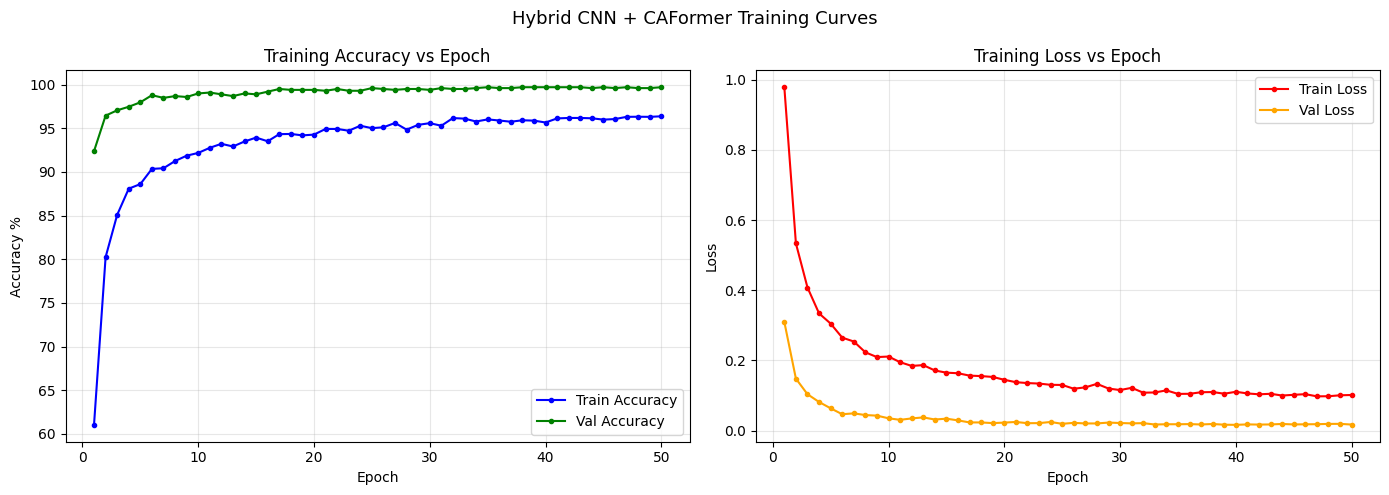

Saved!


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Training Accuracy vs Epoch
axes[0].plot(range(1, CONFIG['epochs']+1), train_accuracies,
             label='Train Accuracy', marker='o', markersize=3, color='blue')
axes[0].plot(range(1, CONFIG['epochs']+1), val_accuracies,
             label='Val Accuracy', marker='o', markersize=3, color='green')
axes[0].set_title('Training Accuracy vs Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy %')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 — Training Loss vs Epoch
axes[1].plot(range(1, CONFIG['epochs']+1), train_losses,
             label='Train Loss', marker='o', markersize=3, color='red')
axes[1].plot(range(1, CONFIG['epochs']+1), val_losses,
             label='Val Loss', marker='o', markersize=3, color='orange')
axes[1].set_title('Training Loss vs Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Hybrid CNN + CAFormer Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'v2_training_curves.png'), dpi=150)
plt.show()
print("Saved!")

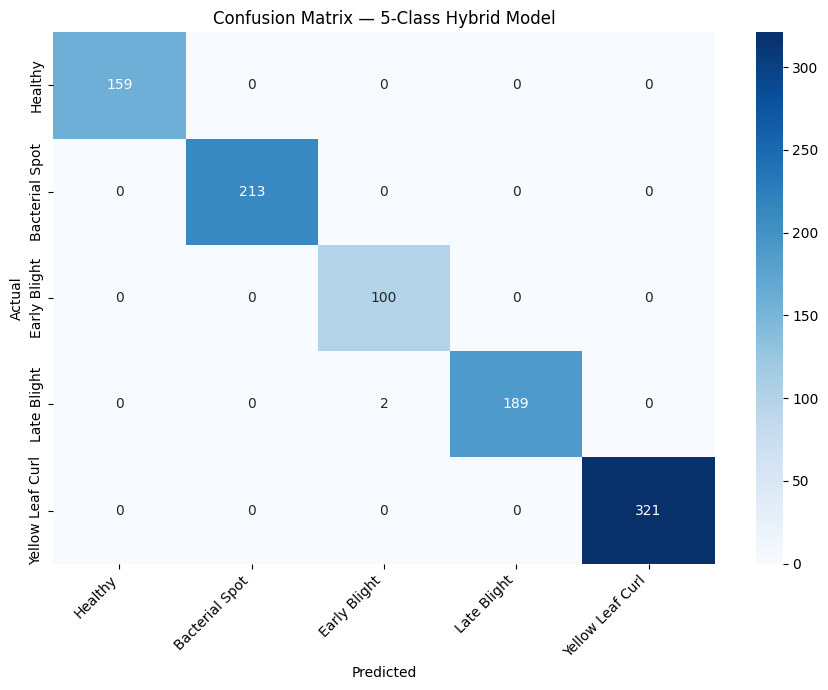


Classification Report:
                  precision    recall  f1-score   support

         Healthy       1.00      1.00      1.00       159
  Bacterial Spot       1.00      1.00      1.00       213
    Early Blight       0.98      1.00      0.99       100
     Late Blight       1.00      0.99      0.99       191
Yellow Leaf Curl       1.00      1.00      1.00       321

        accuracy                           1.00       984
       macro avg       1.00      1.00      1.00       984
    weighted avg       1.00      1.00      1.00       984



In [17]:
# Load best model
checkpoint = torch.load(os.path.join(MODELS, 'best_hybrid_v2.pth'))
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

all_preds, all_labels_list = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds  = model(images).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels_list.extend(labels.numpy())

# Confusion matrix
cm = confusion_matrix(all_labels_list, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names)
plt.title('Confusion Matrix — 5-Class Hybrid Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'v2_confusion_matrix.png'), dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(all_labels_list, all_preds, target_names=short_names))

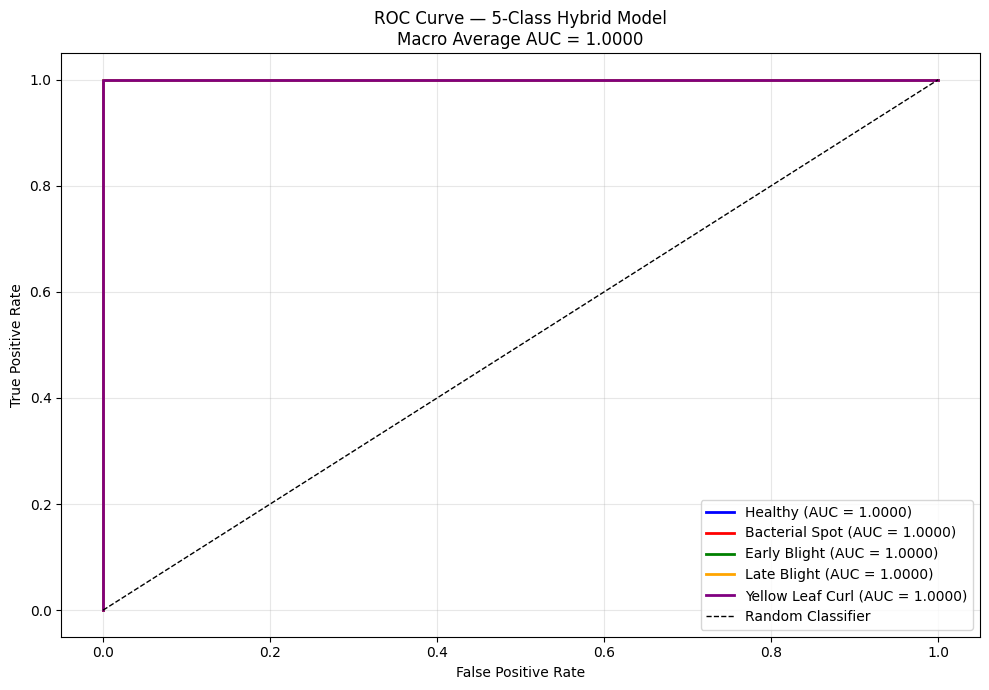


AUC Scores per class:
  Healthy             : 1.0000
  Bacterial Spot      : 1.0000
  Early Blight        : 1.0000
  Late Blight         : 1.0000
  Yellow Leaf Curl    : 1.0000

  Macro Average AUC   : 1.0000


In [18]:
# Get probabilities for all test images
model.eval()
all_probs, all_labels_roc = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model(images)
        probs   = F.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels_roc.extend(labels.numpy())

all_probs      = np.array(all_probs)
all_labels_roc = np.array(all_labels_roc)

# Binarize labels for one-vs-rest ROC
labels_bin = label_binarize(all_labels_roc, classes=list(range(CONFIG['num_classes'])))

# Compute ROC and AUC per class
plt.figure(figsize=(10, 7))
colors = ['blue', 'red', 'green', 'orange', 'purple']
auc_scores = {}

for i, (name, color) in enumerate(zip(short_names, colors)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    auc_val     = auc(fpr, tpr)
    auc_scores[name] = auc_val
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {auc_val:.4f})')

# Macro average AUC
macro_auc = np.mean(list(auc_scores.values()))
plt.plot([0,1], [0,1], 'k--', lw=1, label='Random Classifier')
plt.title(f'ROC Curve — 5-Class Hybrid Model\nMacro Average AUC = {macro_auc:.4f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'v2_roc_curve.png'), dpi=150)
plt.show()

print("\nAUC Scores per class:")
for name, score in auc_scores.items():
    print(f"  {name:20s}: {score:.4f}")
print(f"\n  Macro Average AUC   : {macro_auc:.4f}")

In [19]:
gem_p_final = model.cnn_branch.gem_p.item()

summary = {
    'best_val_accuracy' : best_val_acc,
    'total_params'      : total,
    'trainable_params'  : trainable,
    'gem_p_learned'     : gem_p_final,
    'macro_auc'         : macro_auc,
    'auc_per_class'     : auc_scores,
    'classes'           : SELECTED_CLASSES,
    'epochs_trained'    : CONFIG['epochs'],
}

with open(os.path.join(RESULTS, 'v2_results_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print("=" * 50)
print("FINAL RESULTS SUMMARY")
print("=" * 50)
print(f"Best Val Accuracy  : {best_val_acc:.2f}%")
print(f"Macro Average AUC  : {macro_auc:.4f}")
print(f"Learned GeM p      : {gem_p_final:.4f}")
print(f"Total Params       : {total:,}")
print(f"Trainable Params   : {trainable:,}")
print("=" * 50)

if gem_p_final > 1.5:
    print(f"\nGeM Insight: p={gem_p_final:.2f} > 1 confirms the network")
    print("learned to emphasize high-activation lesion pixels")
    print("over uniform healthy tissue — validating GeM choice.")
else:
    print(f"\nGeM Insight: p={gem_p_final:.2f} ≈ 1 suggests GAP was")
    print("already near-optimal for this dataset.")

FINAL RESULTS SUMMARY
Best Val Accuracy  : 99.69%
Macro Average AUC  : 1.0000
Learned GeM p      : 2.9402
Total Params       : 983
Trainable Params   : 13,971,856

GeM Insight: p=2.94 > 1 confirms the network
learned to emphasize high-activation lesion pixels
over uniform healthy tissue — validating GeM choice.
